# Extended Data Figure 6

Sam Gould, Kexin Dong

Cleaned: May 1, 2026

Last Updated: May 1, 2026

Benchmarking of LFC summarization and p-value combination methods for the ABE screen.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

## 6b

In [ ]:
def plot_effect_size_comparison(df, screen_name, conditions):
    n = len(conditions)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)

    targ = df[df['classification'] == 'targeting guide'].copy()

    for k, cond in enumerate(conditions):
        med = f'LFC_median_{cond}'
        avg = f'LFC_avg_{cond}'
        con = f'LFC_concordant_mean_{cond}'
        if med not in targ.columns:
            continue
        lim = targ[med].abs().quantile(0.99) * 1.1

        # Row 0: median vs mean
        ax = axes[0][k]
        ax.scatter(targ[med], targ[avg], s=5, alpha=0.25, color='tab:blue')
        ax.plot([-lim,lim], [-lim,lim], 'k--', linewidth=0.8)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        _xy = targ[[med, avg]].dropna()
        rp = _xy.corr().iloc[0,1]
        rs, _ = scipy.stats.spearmanr(_xy.iloc[:,0], _xy.iloc[:,1])
        ax.set_title(f'{screen_name} {cond}\n$r_p$={rp:.3f}, $r_s$={rs:.3f}', fontsize=16)
        ax.set_xlabel('Median LFC', fontsize=16); ax.set_ylabel('Mean LFC', fontsize=16)
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=16, direction='out', length=6, width=1)

        # Row 1: median vs concordant mean
        ax2 = axes[1][k]
        if con in targ.columns:
            ambig = targ[con].isna()
            ax2.scatter(targ.loc[~ambig, med], targ.loc[~ambig, con],
                        s=5, alpha=0.25, color='tab:blue', label=f'concordant (n={(-ambig).sum()})')
            ax2.scatter(targ.loc[ambig, med], targ.loc[ambig, med]*0,
                        s=5, alpha=0.3, color='orange', label=f'ambiguous (n={ambig.sum()})', marker='x')
            _xy2 = targ.loc[~ambig, [med, con]].dropna()
            rp2 = _xy2.corr().iloc[0,1]
            rs2, _ = scipy.stats.spearmanr(_xy2.iloc[:,0], _xy2.iloc[:,1])
            ax2.plot([-lim,lim], [-lim,lim], 'k--', linewidth=0.8)
            ax2.set_title(f'$r_p$={rp2:.3f}, $r_s$={rs2:.3f}', fontsize=16)
            ax2.legend(frameon=False, fontsize=12)
        ax2.set_xlim(-lim, lim); ax2.set_ylim(-lim, lim)
        ax2.set_xlabel('Median LFC', fontsize=16); ax2.set_ylabel('Concordant mean LFC', fontsize=16)
        ax2.spines[['top','right']].set_visible(False)
        ax2.tick_params(axis='both', which='major', labelsize=16, direction='out', length=6, width=1)

    fig.tight_layout()
    return fig

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


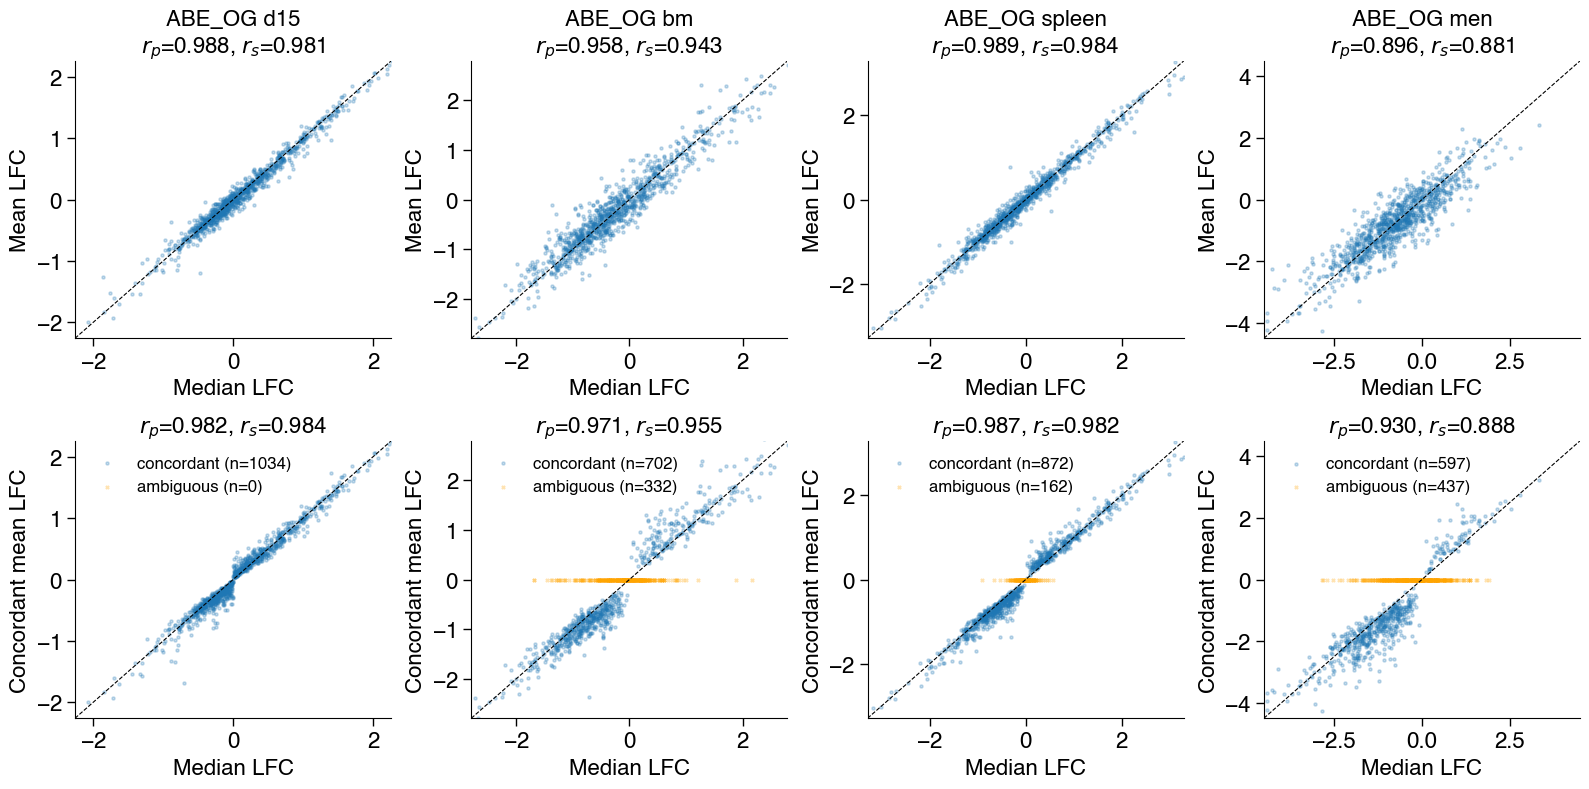

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


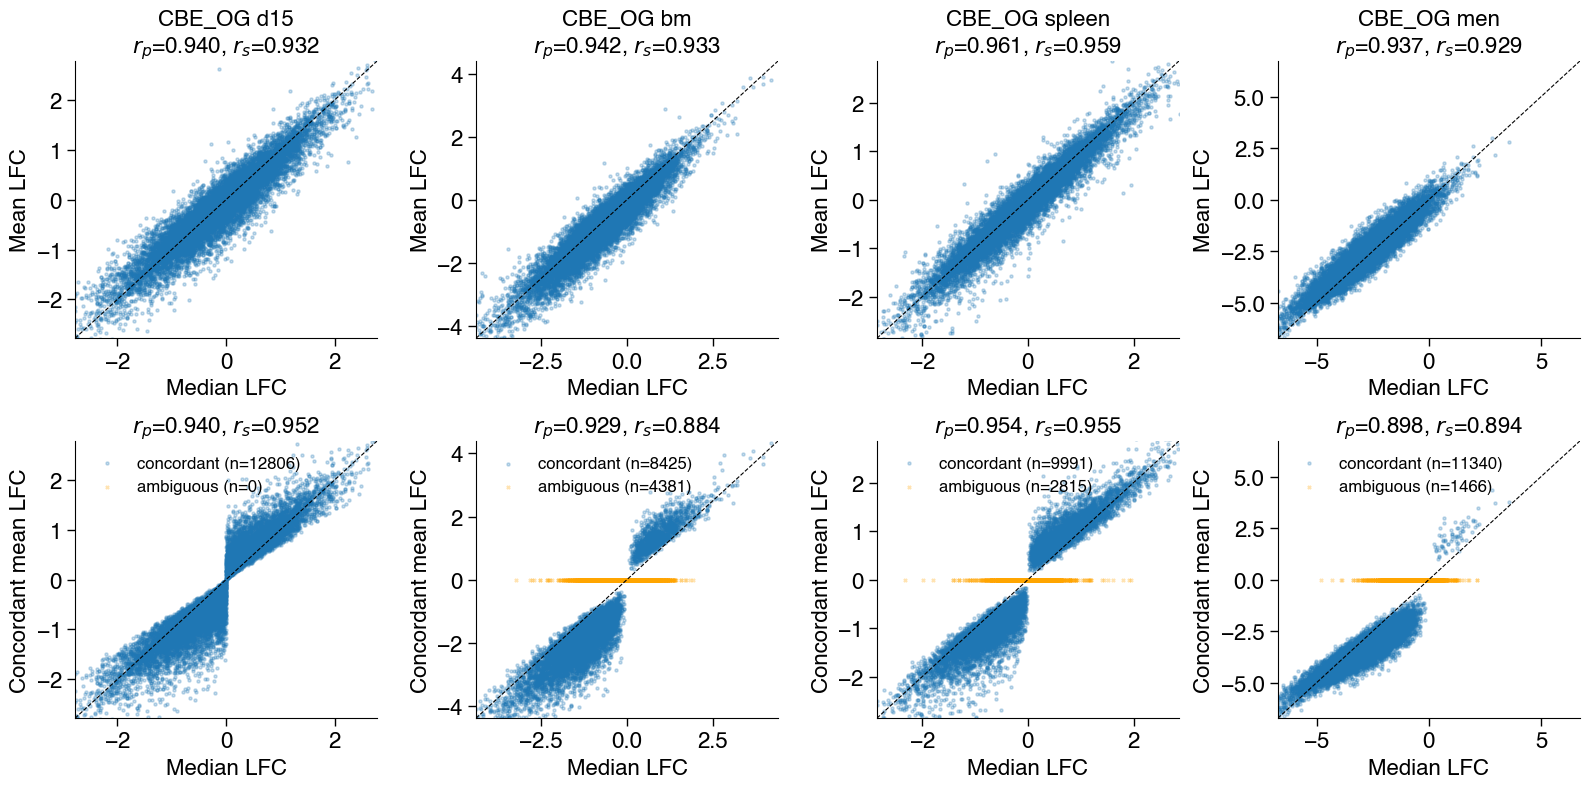

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


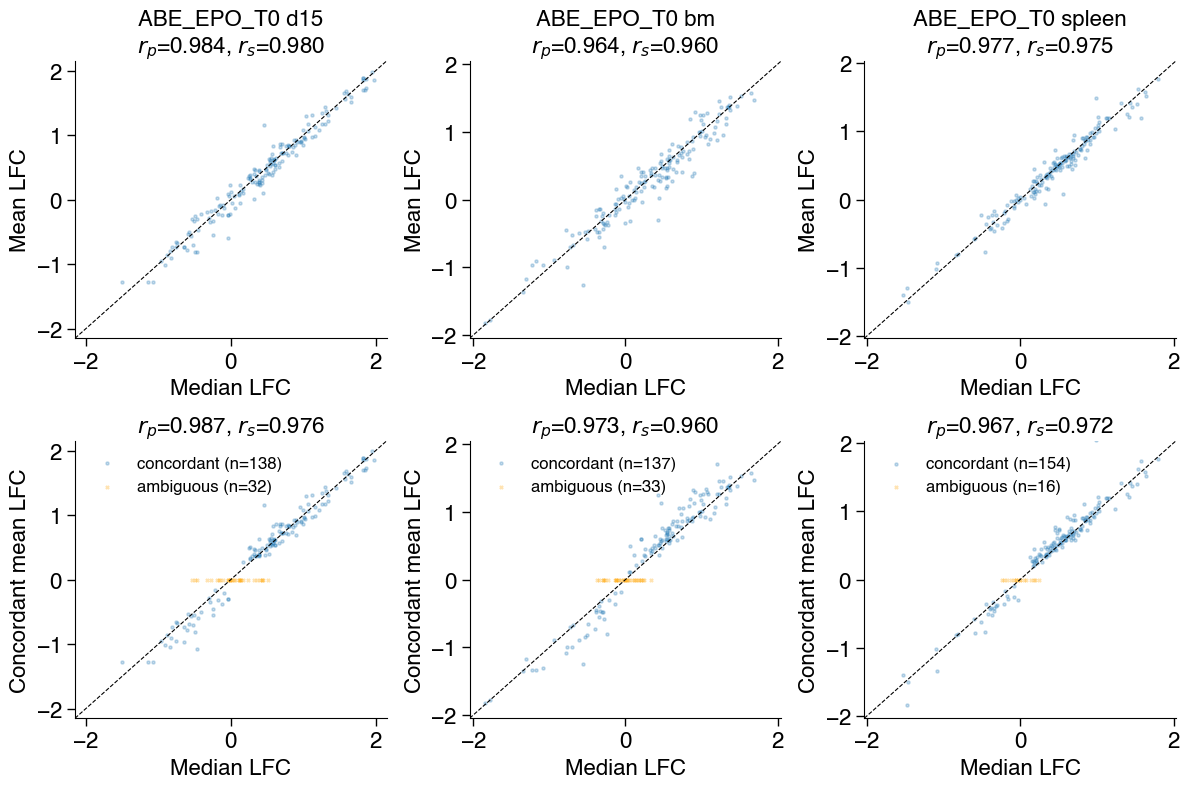

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


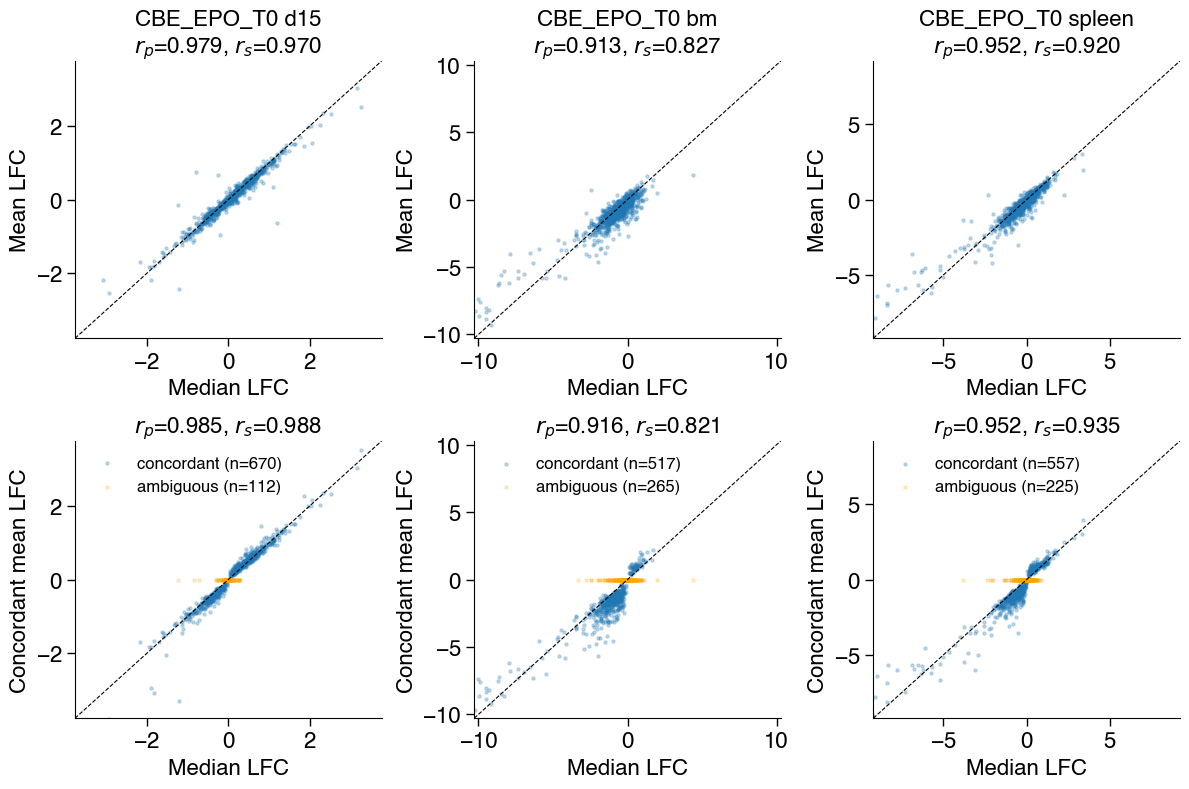

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


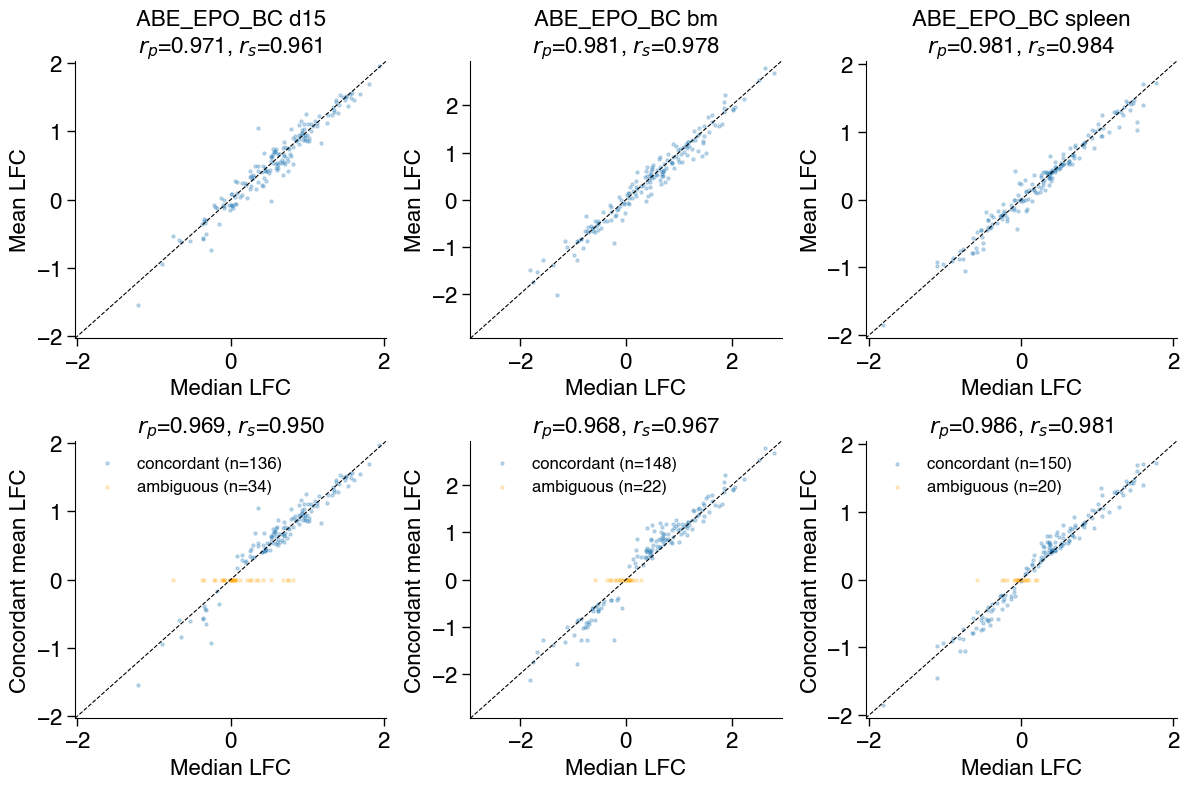

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


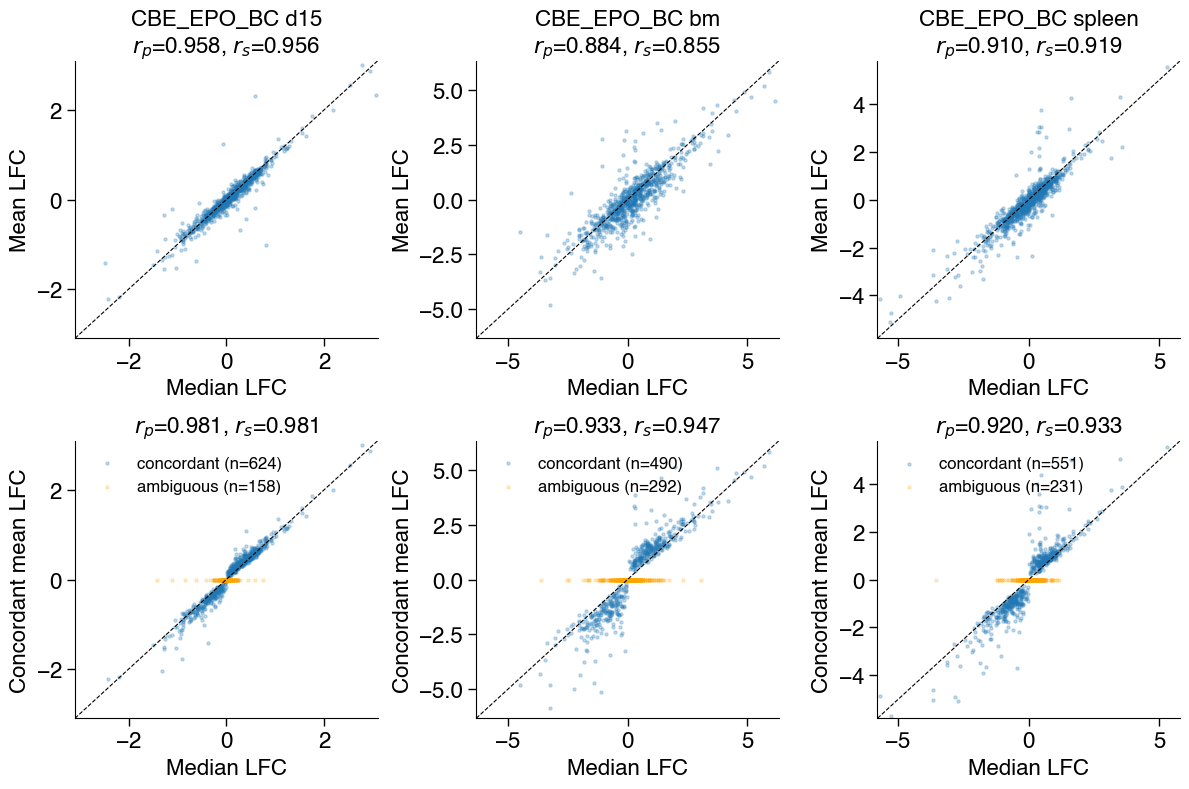

In [ ]:
import os as _os
_os.makedirs(BASE + 'figures_final', exist_ok=True)

for screen, conds in [('ABE_OG', conds_og), ('CBE_OG', conds_og),
                       ('ABE_EPO_T0', conds_focused), ('CBE_EPO_T0', conds_focused),
                       ('ABE_EPO_BC', conds_focused), ('CBE_EPO_BC', conds_focused),
]:
    if dfs.get(screen) is None: continue
    fig = plot_effect_size_comparison(dfs[screen], screen, conds)
    fig.savefig(BASE + f'figures_final/effect_size_comparison_{screen}.pdf', bbox_inches='tight')
    plt.show()


## 6c

Venn diagrams comparing significant hits (FDR < 0.1) identified by Fisher's versus Stouffer's methods for p-value combination across each tissue context in the ABE screen.

In [ ]:
def get_hits(df, condition, fdr_method='fishers', fdr_cutoff=0.1,
             effect='median', lfc_dir='both', lfc_cutoff=1.0, is_og=False):
    # Filters: sensor_reads_{cond} >= min_sensor, target_base_edit_perc_{cond} >= 20,
    #          Input_median >= 2, |LFC| > lfc_cutoff
    # OG screens use min_sensor=10; focused screens use min_sensor=100
    min_sensor  = 10 if is_og else 100
    edit_cutoff = 20

    targ = df[df['classification'] == 'targeting guide'].copy()

    input_ok = targ['Input_median'] >= 2 if 'Input_median' in targ.columns else pd.Series(True, index=targ.index)
    reads_col = f'sensor_reads_{condition}'
    edit_col  = f'target_base_edit_perc_{condition}'
    if reads_col in targ.columns and edit_col in targ.columns:
        guide_ok = input_ok & (targ[reads_col] >= min_sensor) & (targ[edit_col] >= edit_cutoff)
    else:
        guide_ok = input_ok
    targ = targ[guide_ok]

    fdr_col = f'FDR_{condition}_{fdr_method}'
    lfc_col = f'LFC_{effect}_{condition}'
    if fdr_col not in targ.columns:
        return set()
    sig = targ[(targ[fdr_col] < fdr_cutoff) & (targ[lfc_col].abs() > lfc_cutoff)].dropna(subset=[lfc_col])
    if lfc_dir == 'enrich': sig = sig[sig[lfc_col] > 0]
    elif lfc_dir == 'deplet': sig = sig[sig[lfc_col] < 0]
    return set(sig['gRNA_id'])


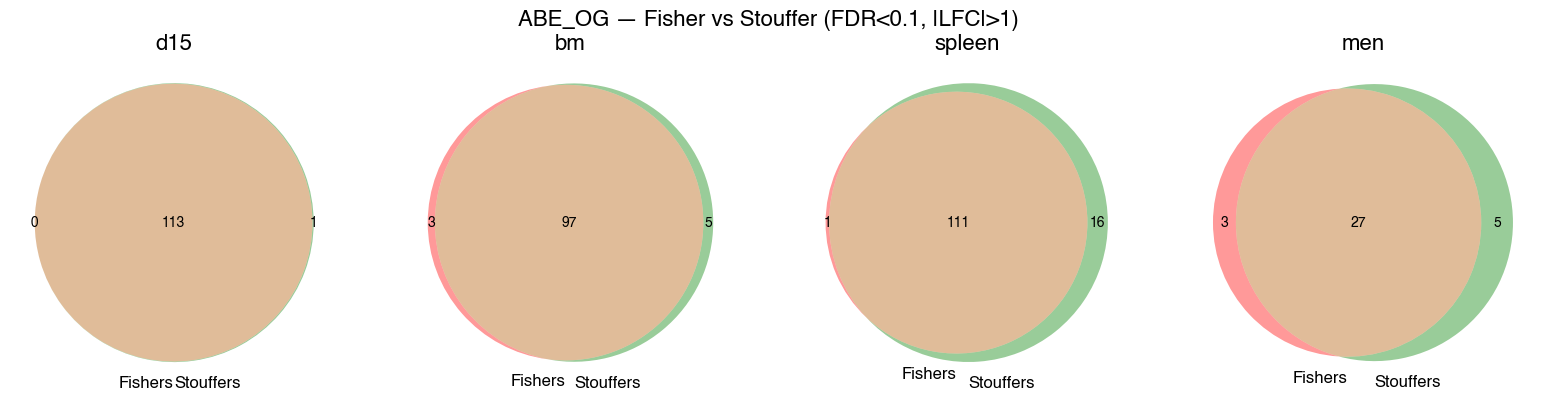

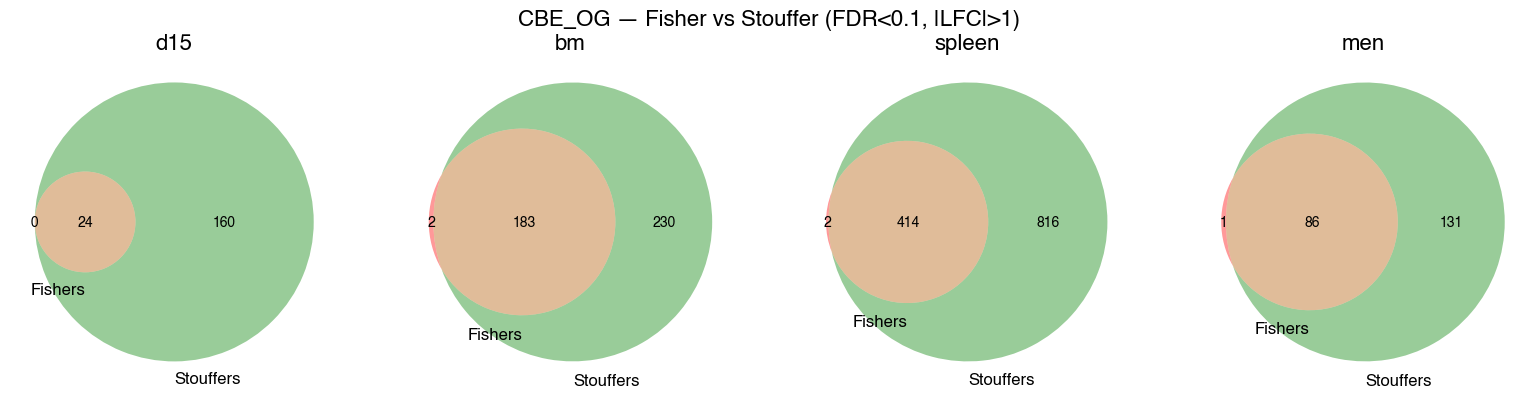

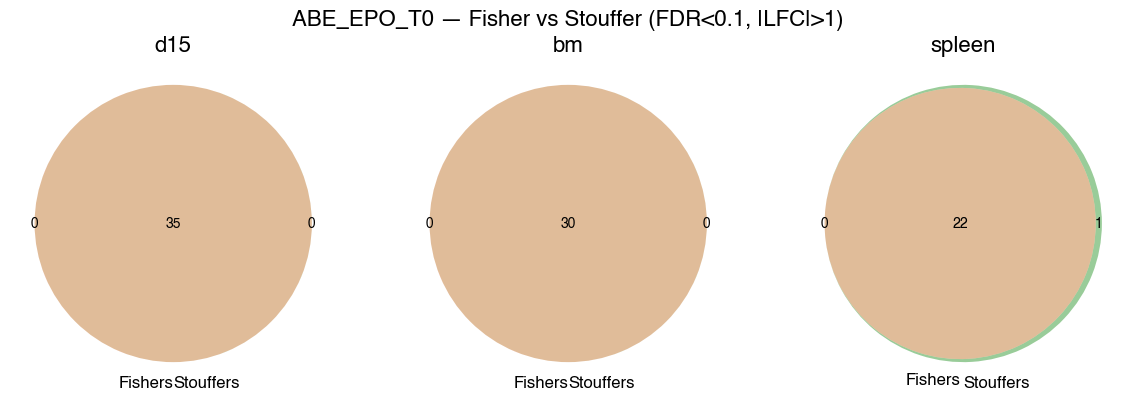

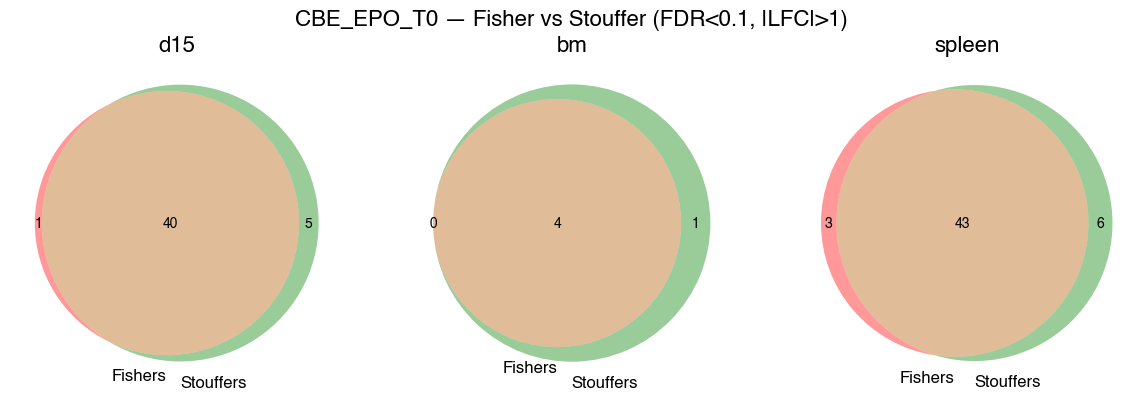

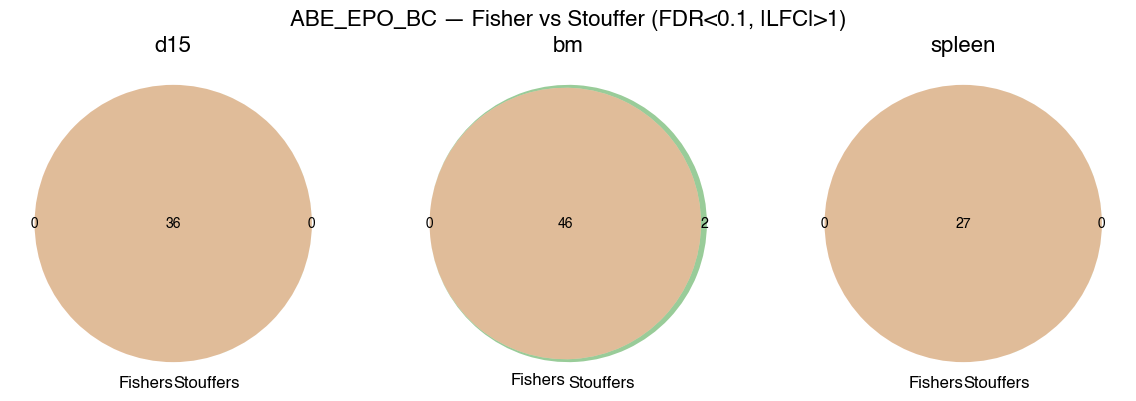

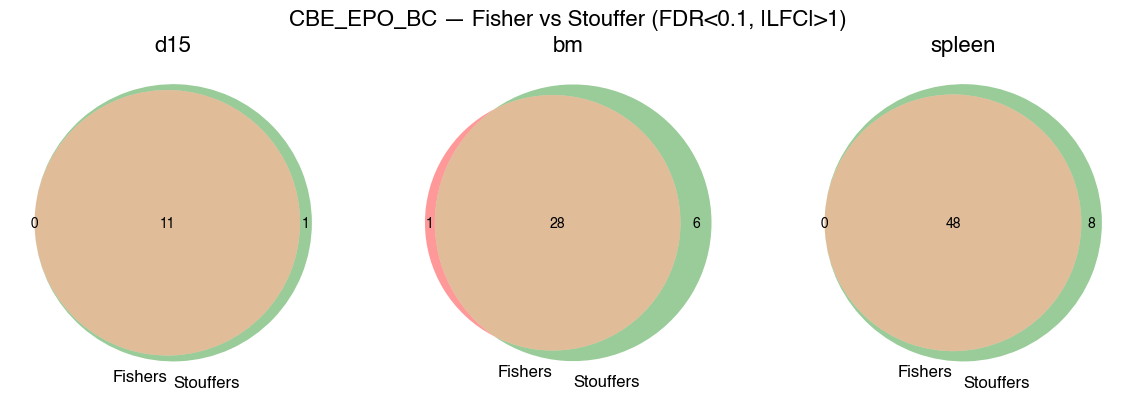

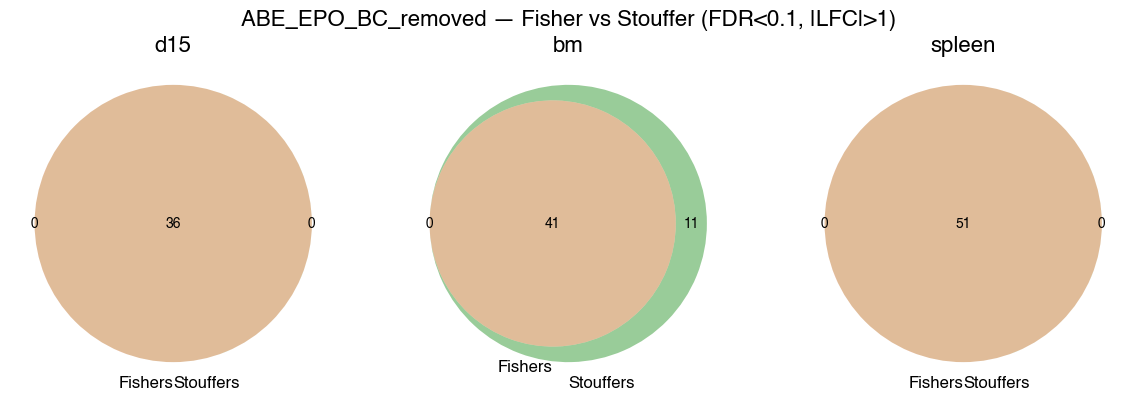

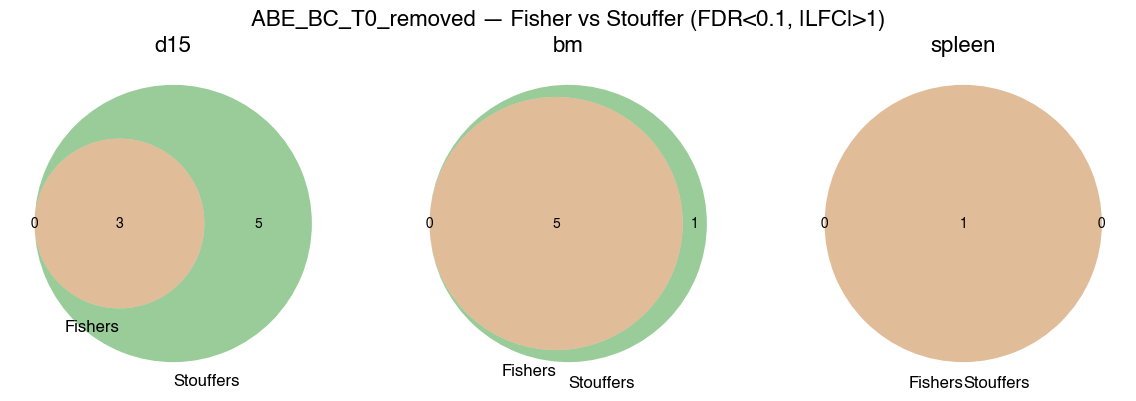

In [ ]:
# Fisher vs Stouffer per screen per condition
for screen, conds, og in [('ABE_OG', conds_og, True), ('CBE_OG', conds_og, True),
                            ('ABE_EPO_T0', conds_focused, False), ('CBE_EPO_T0', conds_focused, False),
                            ('ABE_EPO_BC', conds_focused, False), ('CBE_EPO_BC', conds_focused, False),
]:
    if dfs.get(screen) is None: continue
    n = len(conds)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for k, cond in enumerate(conds):
        venn2([get_hits(dfs[screen], cond, 'fishers',   is_og=og),
               get_hits(dfs[screen], cond, 'stouffers', is_og=og)],
              set_labels=('Fishers','Stouffers'), ax=axes[k])
        axes[k].set_title(cond, fontsize=16)
    fig.suptitle(f'{screen} — Fisher vs Stouffer (FDR<0.1, |LFC|>1)', fontsize=16)
    fig.tight_layout()
    plt.show()
